# Experimento 05 (baseline/Ga+Si)

Investigar a existência de agrupamentos naturais nos dados biomecânicos da marcha do subconjunto Ga e Si utilizando K-Means sem redução dimensional.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ga_file = BASE_PATH / 'ga_baseline_features.csv'
si_file = BASE_PATH / 'si_baseline_features.csv'

ga_df = pd.read_csv(ga_file)
si_df = pd.read_csv(si_file)

In [4]:
combined_df = pd.concat(
    [ga_df, si_df],
    ignore_index=True
)

In [5]:
combined_df.shape

(177, 12)

In [6]:
combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77


In [7]:
combined_df.info()
combined_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          177 non-null    object 
 1   patient_id       177 non-null    object 
 2   mean_total_L     177 non-null    float64
 3   mean_total_R     177 non-null    float64
 4   std_total_L      177 non-null    float64
 5   std_total_R      177 non-null    float64
 6   cv_total_L       177 non-null    float64
 7   cv_total_R       177 non-null    float64
 8   assimetria_mean  177 non-null    float64
 9   assimetria_abs   177 non-null    float64
 10  peak_force_L     177 non-null    float64
 11  peak_force_R     177 non-null    float64
dtypes: float64(10), object(2)
memory usage: 16.7+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,455.897229,454.481270,393.021020,392.600445,0.863696,0.865308,1.415959,27.907006,1077.779379,1075.669492
std,77.975313,70.656537,65.970410,59.576114,0.044913,0.039848,37.462112,24.943941,189.086295,182.718047
min,257.118875,251.897876,226.298854,224.369987,0.638924,0.733060,-88.564178,0.159885,709.720000,678.150000
25%,401.878115,414.511451,349.183754,357.960975,0.845506,0.842951,-22.384324,9.357098,939.730000,941.820000
50%,460.512082,455.374504,390.018246,396.493119,0.868739,0.863891,1.974890,21.170493,1053.910000,1064.030000
75%,495.963251,497.457205,435.329709,425.528346,0.884646,0.885079,18.944752,40.393835,1208.130000,1180.740000
max,665.698361,634.581404,535.490778,539.934434,1.178253,1.163285,122.906652,122.906652,1617.330000,1911.030000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [8]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = combined_df[feature_cols]

# 5. Normalização dos dados

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [10]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

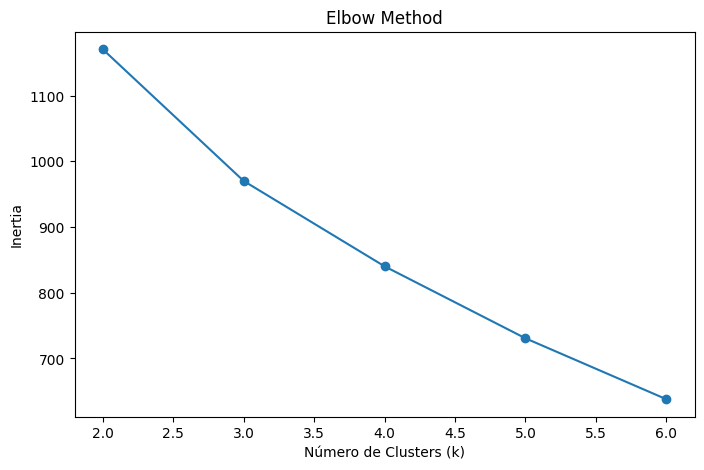

In [11]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [12]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.2914
k=3 | Silhouette Score: 0.2398
k=4 | Silhouette Score: 0.2648
k=5 | Silhouette Score: 0.2684
k=6 | Silhouette Score: 0.2753


Vizualização com o Silhouette Score

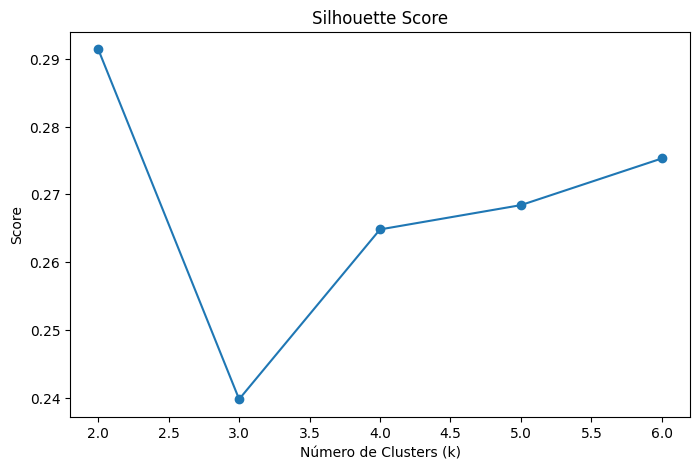

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [14]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [15]:
combined_df['cluster'] = clusters

combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Ga,GaPt24_10,473.238435,502.094442,411.342104,422.206326,0.869207,0.840890,-28.856007,28.856007,1188.55,1210.77,1
1,Ga,GaCo09_02,470.210635,423.825689,409.763042,374.653720,0.871446,0.883981,46.384946,46.384946,1151.26,983.62,0
2,Ga,GaPt14_10,540.243175,425.180815,461.761851,389.215544,0.854730,0.915412,115.062360,115.062360,1276.00,1092.96,1
3,Ga,GaPt08_02,391.887131,419.585864,340.767717,370.100560,0.869556,0.882062,-27.698733,27.698733,904.86,927.74,0
4,Ga,GaPt28_10,591.748944,593.337949,488.596962,482.026601,0.825683,0.812398,-1.589005,1.589005,1324.84,1342.77,1


# 9. Métricas Internas

In [16]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.2914
Davies-Bouldin Index: 1.2334
Calinski-Harabasz Score: 89.5797


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

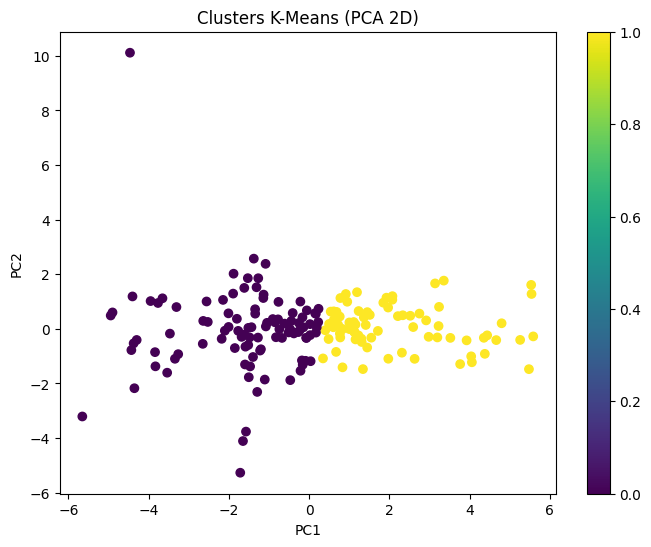

In [18]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [19]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

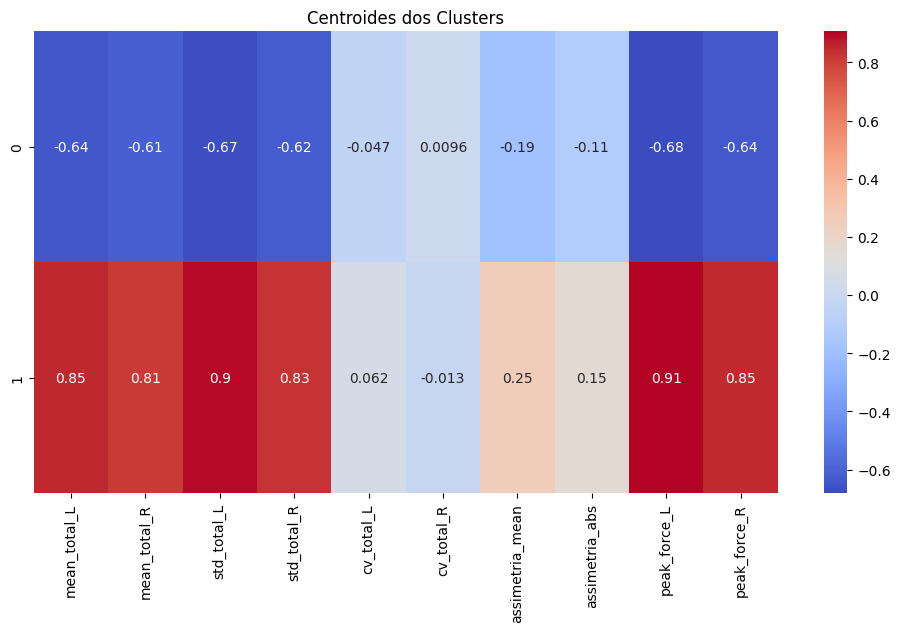

In [20]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters')

plt.show()

# 12. Distribuição dos Clusters

In [21]:
combined_df['cluster'].value_counts()

,count
cluster,
0,101
1,76


# 13. Composição dos clusters por dataset

In [22]:
combined_df.groupby('cluster')['dataset'].value_counts()

cluster  dataset
0        Ga         71
         Si         30
1        Ga         42
         Si         34
Name: count, dtype: int64

# 14. Média das features por cluster e dataset

In [23]:
combined_df.groupby(
    ['cluster', 'dataset']
)[feature_cols].mean()

mean_total_L  mean_total_R  std_total_L  std_total_R  \
cluster dataset                                                         
0       Ga         406.775807    412.189416   347.421852   356.234465   
        Si         404.094899    410.139647   351.748496   353.886805   
1       Ga         539.498613    522.473086   463.065961   449.236326   
        Si         500.909956    497.931684   438.133642   432.738294   

                 cv_total_L  cv_total_R  assimetria_mean  assimetria_abs  \
cluster dataset                                                            
0       Ga         0.857313    0.866200        -5.413609       26.386992   
        Si         0.871715    0.864484        -6.044748       22.053422   
1       Ga         0.859559    0.861150        17.025527       35.609707   
        Si         0.875059    0.869309         2.978272       26.730977   

                 peak_force_L  peak_force_R  
cluster dataset                              
0       Ga         950.221831    963.341268  
        Si         946.704000    950.539333  
1       Ga        1264.861190   1244.120952  
        Si        1228.703235   1212.559118